# CH5 雙變數圖表 (Bivariate Plots)

## 簡介  
雙變數圖表主要用來觀察與呈現「兩個變數」之間的關係、數值比較或分佈情形。常見的圖表包括：
- 用來觀察兩個數值型變數關係的**散佈圖 (Scatter Plot)**
- 呈現兩個分類變數數值比較的**群組長條圖 (Grouped Bar Chart)**
- 適合展示矩陣資料（如變數間相關係數）的**熱力圖 (Heatmap)**
- 以及從散佈圖延伸、透過大小呈現第三維度數值的**氣泡圖 (Bubble Chart)**




## 5.1 散佈圖（Scatter Plot）

### 1. 定義  
散佈圖用來觀察兩個數值型變數之間的關係與分佈情形，每一筆資料以一個點標示於平面座標中。


### 2. 範例圖表與說明  


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
path = '/content/drive/MyDrive/Colab Notebooks/CH5_dataset/datasets'
img_path = '/content/drive/MyDrive/Colab Notebooks/CH5_dataset/images'

Mounted at /content/drive


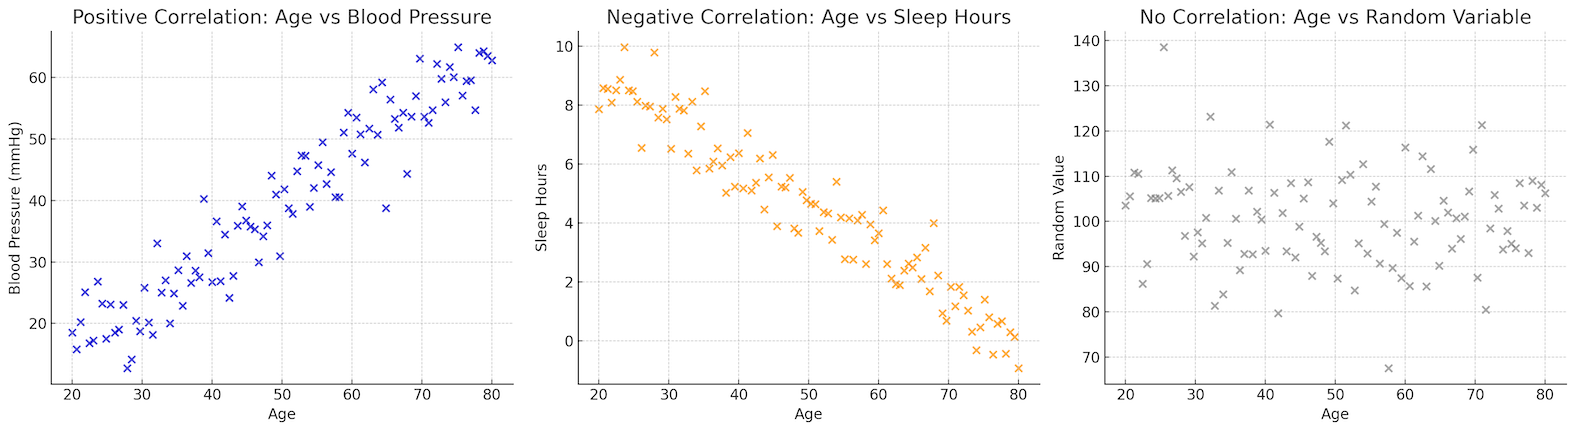

In [ ]:
from IPython import display

display.Image(img_path +"/"+ 'Scatter-1.png', width = 600)

**觀察與解釋：**

- **圖 (a) Positive Correlation：年齡 vs 血壓**  
  點分布呈上升趨勢，表示隨著年齡增加，血壓也有上升的趨勢，兩者呈現**正相關**。

- **圖 (b) Negative Correlation：年齡 vs 睡眠時數**  
  點分布呈下降趨勢，顯示年齡愈大，平均睡眠時間較短，兩者呈現**負相關**。

- **圖 (c) No Correlation：年齡 vs 隨機變數**  
  點分布毫無趨勢與規律，兩變數間**無顯著相關**。

### 3. 適用情況  
- 觀察數值變數之間的關聯性  
- 偵測群聚分布、趨勢線、異常值  
- 建立迴歸或預測模型的基礎


### 4. 優缺點  
- **優點**：  
  - 能清楚呈現變數間的關係與分佈形態  
  - 可加入色彩與大小進行進一步維度分析  
- **缺點**：  
  - 對類別型資料不適用  
  - 資料點數量過多時容易重疊不易閱讀


### 5. 實際案例與圖表  

- **醫療領域**：年齡與血壓關聯分析  
- **電子商務**：每筆訂單金額與購買次數關係  
- **製造領域**：機器使用時間與維修次數關係圖


### 6. 實作範例：醫學領域 - 年齡與血糖值的關聯分析（Scatter Plot）

#### 📁 資料說明

模擬 200 筆病患資料，記錄其年齡、BMI（身體質量指數）、血糖值與性別資訊。

| Patient_ID | Age | BMI  | Blood_Sugar | Gender |
|------------|-----|------|-------------|--------|
| 1          | 51  | 22.5 | 121.3       | Male   |
| 2          | 67  | 27.1 | 143.9       | Female |
| ...        | ... | ...  | ...         | ...    |



#### 💻 實作目標

透過 Seaborn 套件繪製散佈圖，練習以下技能：

- 使用 `sns.scatterplot()` 繪製兩變數的關係圖  
- 加入 `hue`, `size`, `style` 參數表達第三維資訊  
- 練習配色、大小設定與透明度調整  
- 強化多變數視覺化表達能力

`sns.scatterplot()`: [API Doc](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)

   Patient_ID  Age   BMI  Blood_Sugar  Gender
0           1   58  30.5        128.9    Male
1           2   71  27.3        150.9  Female
2           3   48  25.2        120.7    Male
3           4   34  27.6        116.5    Male
4           5   62  21.6        115.8    Male


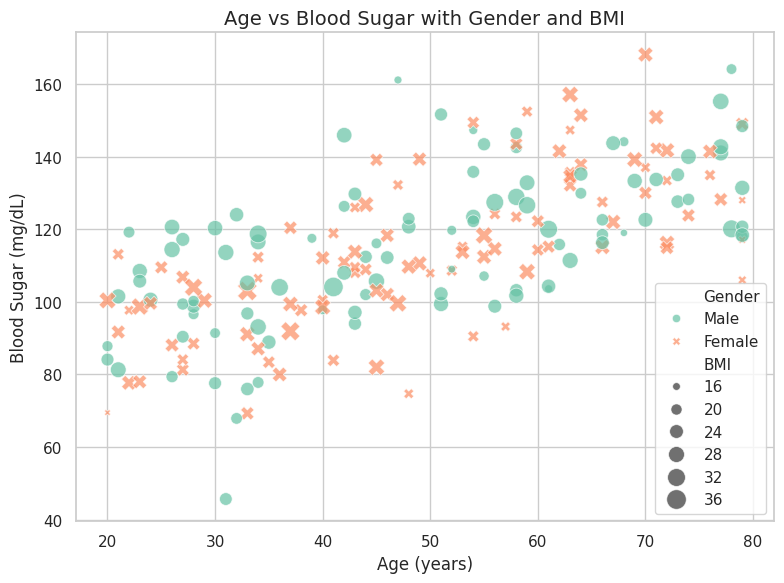

In [ ]:
# 匯入所需套件
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 讀取資料集
from pathlib import Path

data_file = "patient_age_bmi_bloodsugar_gender.csv"

df = pd.read_csv(path+"/"+data_file)

# 檢查資料前幾列
print(df.head())

# 設定 Seaborn 畫圖風格
sns.set(style="whitegrid")

# 建立圖表區域與尺寸
plt.figure(figsize=(8, 6))

# 使用 Seaborn 繪製散佈圖
sns.scatterplot(
    data=df,
    x="Age",                     # X 軸變數：年齡
    y="Blood_Sugar",             # Y 軸變數：血糖值
    hue="Gender",                # 顏色區分：性別分類
    size="BMI",                  # 點大小依據：BMI 連續值
    palette="Set2",              # 使用 Seaborn 預設分類配色
    sizes=(20, 200),             # 點大小範圍
    style="Gender",              # 點樣式依性別區分
    alpha=0.7                    # 透明度
)

# 設定標題與標籤
plt.title("Age vs Blood Sugar with Gender and BMI", fontsize=14)
plt.xlabel("Age (years)", fontsize=12)
plt.ylabel("Blood Sugar (mg/dL)", fontsize=12)

# 顯示圖表
plt.tight_layout()
plt.show()

### Try it!：6. 實作範例：醫學領域 - 年齡與血糖值的關聯分析（Scatter Plot）
臨床上空腹血糖大於等於 126 mg/dL 常被視為糖尿病警戒值，把這群病患在圖上標出來。

**程式要求**
1. 讀取 `datasets/patient_age_bmi_bloodsugar_gender.csv`，篩出 `Blood_Sugar >= 126` 的病患並印出人數。
2. 繪製散佈圖：一般病患用灰色、高血糖病患用紅色。
3. 在 126 的位置加上水平警戒線與圖例。

#### 📌 常用參數與設定值說明

| 參數        | 說明                              | 範例設定值                         |
|-------------|-----------------------------------|------------------------------------|
| `x`, `y`    | 數值變數的座標軸設定              | `"Age"`, `"Blood_Sugar"`           |
| `hue`       | 顏色分類（類別或連續變數）        | `"Gender"`, `"BMI"`                |
| `size`      | 點大小（通常為連續變數）          | `"BMI"`                            |
| `style`     | 點樣式（通常為類別變數）          | `"Gender"`                         |
| `palette`   | 調色盤類型                        | `"Set2"`, `"coolwarm"`, `"viridis"`|
| `sizes`     | 點大小範圍（min, max）             | `(20, 200)`                        |
| `alpha`     | 透明度（0~1）                     | `0.6`, `0.8`, `1.0`                |


#### 📝 練習任務建議

1. **任務一：改變 `hue` 顯示連續變數 BMI**  
   觀察以 BMI 色彩區分的效果與精細度。

2. **任務二：移除 `size` 僅以顏色呈現性別分類**  
   讓圖形簡潔但保留區分類別。

3. **任務三：嘗試不同調色盤如 `coolwarm`, `plasma`**  
   比較冷暖系與分類色在識別度上的差異。

4. **任務四：新增 `style='Gender'` 將性別用圖形區分**  
   結合色彩與圖形進行視覺強化。

5. **任務五：改用 `sns.regplot()` 加入迴歸線分析趨勢**  
   加入線性趨勢線來輔助解釋變數關係。
